# Module 3 — Data Collection & Dataset Preparation

**Social Media Bot Detection Using GNN**

Full data pipeline:
```
Raw CSVs  ->  Load  ->  Inspect formats (CSV / JSON / Edge list)
          ->  Remove duplicates
          ->  Handle missing values
          ->  Fix data types
          ->  Cap outliers
          ->  Validate user IDs
          ->  Encode labels
          ->  Separate node / edge tables
          ->  Train / Val / Test split
          ->  Save processed files
```


In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ROOT          = Path(r'c:\Social Media Bot Detection')
RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
SPLITS_DIR    = ROOT / 'data' / 'splits'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: 'human', 1: 'bot', 2: 'suspicious'}
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')
print('All libraries loaded.  ROOT:', ROOT)

All libraries loaded.  ROOT: c:\Social Media Bot Detection


## 3.1 Load & Inspect Raw Data

In [2]:
users_raw  = pd.read_csv(RAW_DIR / 'users.csv',  low_memory=False)
tweets_raw = pd.read_csv(RAW_DIR / 'tweets.csv', low_memory=False)
edges_raw  = pd.read_csv(RAW_DIR / 'edges.csv',  low_memory=False)
print(f'[RAW] users  : {len(users_raw):>7,} rows x {users_raw.shape[1]} cols')
print(f'[RAW] tweets : {len(tweets_raw):>7,} rows x {tweets_raw.shape[1]} cols')
print(f'[RAW] edges  : {len(edges_raw):>7,} rows x {edges_raw.shape[1]} cols')

[RAW] users  :  10,000 rows x 23 cols
[RAW] tweets : 137,774 rows x 11 cols
[RAW] edges  :  55,000 rows x 5 cols


In [3]:
users_raw.head()

,user_id,screen_name,account_type,label,created_at,account_age_days,followers_count,following_count,post_count,verified,posts_per_day,reply_ratio,retweet_ratio,mention_ratio,url_ratio,hashtag_ratio,duplicate_content_ratio,has_profile_image,has_description,default_profile,profile_completeness,location,listed_count
0,106253,user_106253,bot,1,2023-03-03,304,3,4315,1479,0,5.0000,0.2397,0.8602,0.0526,0.8390,0.1972,0.8067,0,0,1,0.1698,"California, USA",2.0000
1,104685,user_104685,human,0,2020-10-11,1177,102,99,84,0,4.4608,0.0933,0.2213,0.0554,0.1738,0.3302,0.0032,1,1,1,0.5291,"Toronto, Canada",24.0000
2,101732,user_101732,human,0,2019-08-25,1590,87,4605,491,0,5.5889,0.4229,0.4414,0.2078,0.1655,0.0173,0.1337,1,1,0,0.8951,"Sydney, Australia",41.0000
3,104743,user_104743,human,0,2019-01-27,1800,36,436,166,0,2.1044,0.3324,0.0949,0.0152,0.5728,0.3728,0.0093,0,1,0,0.7602,"Seoul, South Korea",12.0000
4,104522,user_104522,human,0,2017-04-23,2444,6462,294,541,0,0.1000,0.1170,0.3336,0.0294,0.1273,0.0680,0.0373,1,1,0,0.7531,"Berlin, Germany",80.0000


## 3.2 Dataset Format Inspection (CSV / JSON / Edge List)

In [4]:
print('== CSV FORMAT (first 3 rows) ==')
print(users_raw.head(3).to_string(index=False))
print()
with open(RAW_DIR / 'dataset_info.json') as f:
    meta = json.load(f)
print('== JSON FORMAT (statistics) ==')
print(json.dumps(meta['statistics'], indent=2))
print()
print('== EDGE LIST FORMAT (first 5) ==')
print(edges_raw[['source_user_id','target_user_id','interaction_type','weight']].head(5).to_string(index=False))

== CSV FORMAT (first 3 rows) ==
 user_id screen_name account_type  label created_at  account_age_days  followers_count  following_count  post_count  verified  posts_per_day  reply_ratio  retweet_ratio  mention_ratio  url_ratio  hashtag_ratio  duplicate_content_ratio  has_profile_image  has_description  default_profile  profile_completeness          location  listed_count
  106253 user_106253          bot      1 2023-03-03               304                3             4315        1479         0         5.0000       0.2397         0.8602         0.0526     0.8390         0.1972                   0.8067                  0                0                1                0.1698   California, USA        2.0000
  104685 user_104685        human      0 2020-10-11              1177              102               99          84         0         4.4608       0.0933         0.2213         0.0554     0.1738         0.3302                   0.0032                  1                1              

## 3.3a Duplicate Check & Removal

In [5]:
print(f'Duplicate user_ids  : {users_raw.duplicated(subset="user_id").sum():,}')
print(f'Duplicate tweet_ids : {tweets_raw.duplicated(subset="tweet_id").sum():,}')
print(f'Duplicate edge keys : {edges_raw.duplicated(subset=["source_user_id","target_user_id","interaction_type"]).sum():,}')

users_clean  = users_raw.drop_duplicates(subset='user_id').copy()
tweets_clean = tweets_raw.drop_duplicates(subset='tweet_id').copy()
edges_clean  = edges_raw.drop_duplicates(
    subset=['source_user_id','target_user_id','interaction_type']).copy()
print(f'After dedup: users={len(users_clean):,}  tweets={len(tweets_clean):,}  edges={len(edges_clean):,}')

Duplicate user_ids  : 0
Duplicate tweet_ids : 0
Duplicate edge keys : 0
After dedup: users=10,000  tweets=137,774  edges=55,000


## 3.3b Missing Value Analysis

In [6]:
def missing_report(df, name):
    m = df.isnull().sum()
    pct = (m / len(df) * 100).round(2)
    rep = pd.DataFrame({'count': m, 'pct': pct})
    rep = rep[rep['count'] > 0].sort_values('pct', ascending=False)
    print(f'[{name}] Missing: {len(rep)} columns')
    if len(rep):
        print(rep.to_string())
    else:
        print('  None')
    return rep

miss_users  = missing_report(users_clean,  'users')
miss_tweets = missing_report(tweets_clean, 'tweets')
miss_edges  = missing_report(edges_clean,  'edges')

[users] Missing: 2 columns
              count     pct
location       3042 30.4200
listed_count    817  8.1700
[tweets] Missing: 0 columns
  None
[edges] Missing: 0 columns
  None


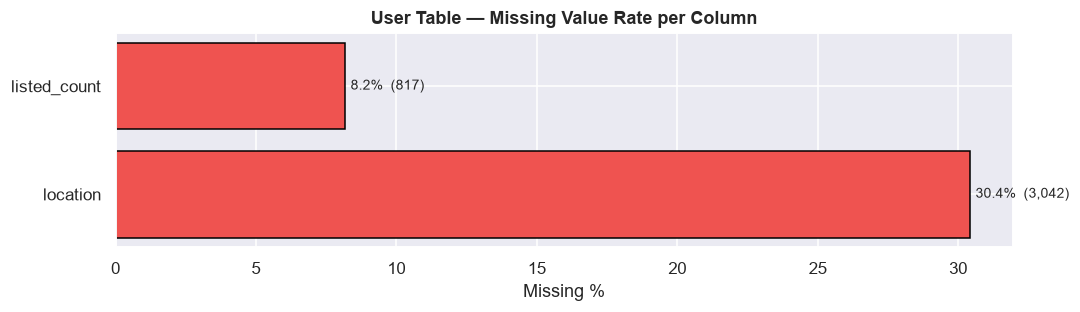

In [7]:
if len(miss_users):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.barh(miss_users.index, miss_users['pct'], color='#EF5350', edgecolor='black')
    ax.set_xlabel('Missing %')
    ax.set_title('User Table — Missing Value Rate per Column', fontweight='bold')
    for i, (col, row) in enumerate(miss_users.iterrows()):
        ax.text(row['pct']+0.2, i,
                f"{row['pct']:.1f}%  ({int(row['count']):,})", va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / 'missing_values.png'), bbox_inches='tight', dpi=120)
    plt.show()

## 3.3c Handle Missing Values

In [8]:
# location  -> fill with 'Unknown'
# listed_count -> fill with per-type median
users_clean['location'] = users_clean['location'].fillna('Unknown')
if 'listed_count' in users_clean.columns:
    med = users_clean.groupby('account_type')['listed_count'].transform('median')
    users_clean['listed_count'] = users_clean['listed_count'].fillna(med).fillna(0).astype(int)

print(f'Total NaN after fill: {users_clean.isnull().sum().sum()}')

Total NaN after fill: 0


## 3.3d Fix Data Types

In [9]:
users_clean['created_at']  = pd.to_datetime(users_clean['created_at'])
tweets_clean['timestamp']  = pd.to_datetime(tweets_clean['timestamp'])
edges_clean['timestamp']   = pd.to_datetime(edges_clean['timestamp'])
for col in ['verified','has_profile_image','has_description','default_profile']:
    users_clean[col] = users_clean[col].astype(int)
print('Types fixed.')
print(users_clean[['created_at','verified','has_profile_image']].dtypes.to_string())

Types fixed.
created_at           datetime64[us]
verified                      int64
has_profile_image             int64


## 3.3e Outlier Capping (99th Percentile)

In [10]:
cap_cols = ['followers_count','following_count','post_count','posts_per_day','listed_count']
caps = {}
print('Capping at 99th percentile:')
for col in cap_cols:
    p99 = users_clean[col].quantile(0.99)
    n = (users_clean[col] > p99).sum()
    users_clean[col] = users_clean[col].clip(upper=p99)
    caps[col] = float(p99)
    print(f'  {col:<25}  cap={p99:>10.1f}  rows_capped={n}')
with open(PROCESSED_DIR / 'outlier_caps.json', 'w') as f:
    json.dump(caps, f, indent=2)
print('\nSaved outlier_caps.json')

Capping at 99th percentile:
  followers_count            cap=    7509.2  rows_capped=100
  following_count            cap=   15845.0  rows_capped=100
  post_count                 cap=   43401.7  rows_capped=100
  posts_per_day              cap=     105.8  rows_capped=100
  listed_count               cap=     210.0  rows_capped=100

Saved outlier_caps.json


## 3.4 Consistent User IDs (0-based node_idx for PyTorch Geometric)

In [11]:
valid_ids = set(users_clean['user_id'].unique())
invalid_tweets = (~tweets_clean['user_id'].isin(valid_ids)).sum()
print(f'Orphan tweet rows   : {invalid_tweets:,}')

tweets_clean = tweets_clean[tweets_clean['user_id'].isin(valid_ids)].copy()
edges_clean  = edges_clean[
    edges_clean['source_user_id'].isin(valid_ids) &
    edges_clean['target_user_id'].isin(valid_ids)
].copy()

uid_sorted = sorted(users_clean['user_id'].unique())
uid_to_idx = {uid: idx for idx, uid in enumerate(uid_sorted)}
users_clean['node_idx']    = users_clean['user_id'].map(uid_to_idx)
edges_clean['src_idx']     = edges_clean['source_user_id'].map(uid_to_idx)
edges_clean['tgt_idx']     = edges_clean['target_user_id'].map(uid_to_idx)

with open(PROCESSED_DIR / 'uid_to_idx.json', 'w') as f:
    json.dump({str(k): v for k, v in uid_to_idx.items()}, f)
print(f'node_idx range: 0 ... {users_clean["node_idx"].max()}')

Orphan tweet rows   : 0


node_idx range: 0 ... 9999


## 3.5 Label Encoding

In [12]:
label_encoding = {
    'int_to_str': {0: 'human', 1: 'bot', 2: 'suspicious'},
    'str_to_int': {'human': 0, 'bot': 1, 'suspicious': 2}
}
with open(PROCESSED_DIR / 'label_encoding.json', 'w') as f:
    json.dump(label_encoding, f, indent=2)

itype_le = LabelEncoder()
edges_clean['interaction_type_enc'] = itype_le.fit_transform(edges_clean['interaction_type'])
itype_map = {k: int(v) for k, v in zip(itype_le.classes_, itype_le.transform(itype_le.classes_))}
with open(PROCESSED_DIR / 'interaction_encoding.json', 'w') as f:
    json.dump(itype_map, f, indent=2)

print('Label encoding: 0=human  1=bot  2=suspicious')
total = len(users_clean)
for lbl, cnt in users_clean['label'].value_counts().sort_index().items():
    name = label_encoding['int_to_str'][lbl]
    w = round(total / (3 * cnt), 4)
    print(f'  label={lbl}  {name:<12}  count={cnt:,}  class_weight={w}')
print(f'Interaction type encoding: {itype_map}')

Label encoding: 0=human  1=bot  2=suspicious


  label=0  human         count=5,000  class_weight=0.6667
  label=1  bot           count=3,500  class_weight=0.9524
  label=2  suspicious    count=1,500  class_weight=2.2222
Interaction type encoding: {'follows': 0, 'mentions': 1, 'replies': 2, 'retweets': 3}


## 3.6 Separate Node and Edge Information

In [13]:
NODE_FEATURE_COLS = ['account_age_days', 'followers_count', 'following_count', 'post_count', 'listed_count', 'verified', 'has_profile_image', 'has_description', 'default_profile', 'profile_completeness', 'posts_per_day', 'reply_ratio', 'retweet_ratio', 'mention_ratio', 'url_ratio', 'hashtag_ratio', 'duplicate_content_ratio']

IDENTITY_COLS = ['user_id','node_idx','screen_name','account_type','label','created_at','location']
EDGE_COLS = ['source_user_id','target_user_id','src_idx','tgt_idx',
             'interaction_type','interaction_type_enc','weight','timestamp']

nodes_df = users_clean[IDENTITY_COLS + NODE_FEATURE_COLS].copy()
edges_df = edges_clean[EDGE_COLS].copy()

print(f'Node feature matrix : {nodes_df.shape}')
print(f'Edge feature matrix : {edges_df.shape}')
print(f'NaN in node features: {nodes_df[NODE_FEATURE_COLS].isnull().sum().sum()}')
print(f'NaN in edge indices : {edges_df[["src_idx","tgt_idx"]].isnull().sum().sum()}')

Node feature matrix : (10000, 24)


Edge feature matrix : (55000, 8)
NaN in node features: 0
NaN in edge indices : 0


## 3.7 Feature Type Categorization

feature_types.json saved.


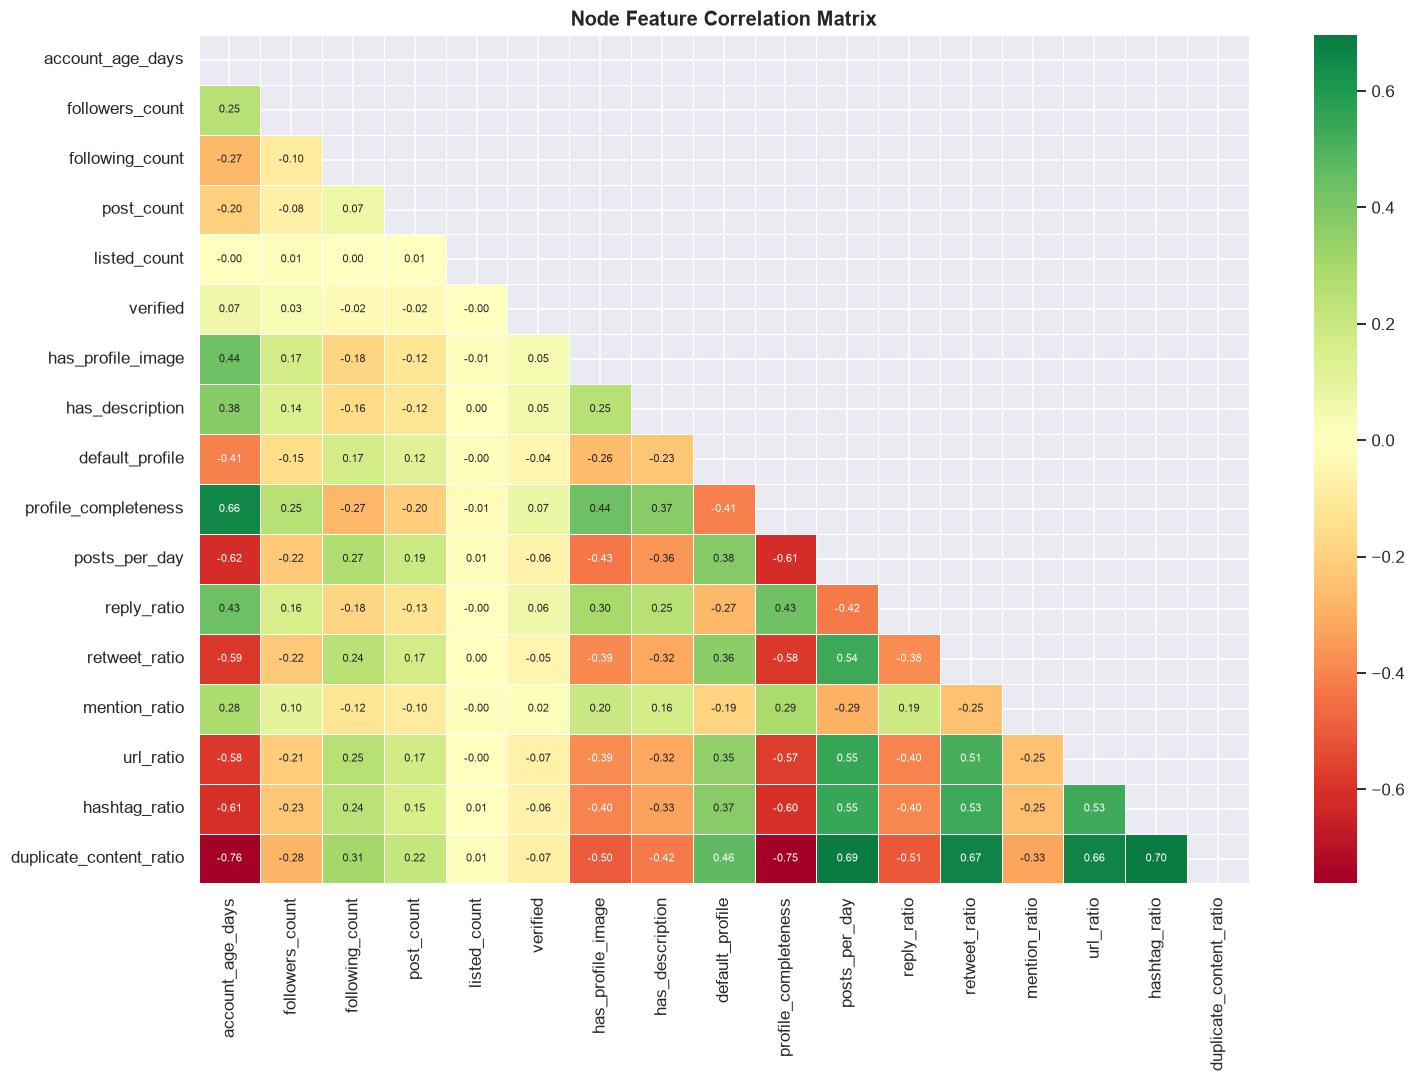

In [14]:
feature_types = {
    'continuous':  ['account_age_days','followers_count','following_count',
                    'post_count','listed_count','posts_per_day','profile_completeness'],
    'ratio_0_1':   ['reply_ratio','retweet_ratio','mention_ratio',
                    'url_ratio','hashtag_ratio','duplicate_content_ratio'],
    'binary':      ['verified','has_profile_image','has_description','default_profile'],
    'normalisation': {
        'continuous': 'StandardScaler (applied in Module 4)',
        'ratio_0_1':  'Already 0-1, optional MinMaxScaler',
        'binary':     'No normalisation'
    }
}
with open(PROCESSED_DIR / 'feature_types.json', 'w') as f:
    json.dump(feature_types, f, indent=2)
print('feature_types.json saved.')

fig, ax = plt.subplots(figsize=(14, 10))
corr = nodes_df[NODE_FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Node Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'feature_correlation.png'), bbox_inches='tight', dpi=120)
plt.show()

## 3.8 Train / Validation / Test Split (70/15/15 — Stratified)

Train : 7,000  (70.0%)
Val   : 1,500  (15.0%)
Test  : 1,500  (15.0%)


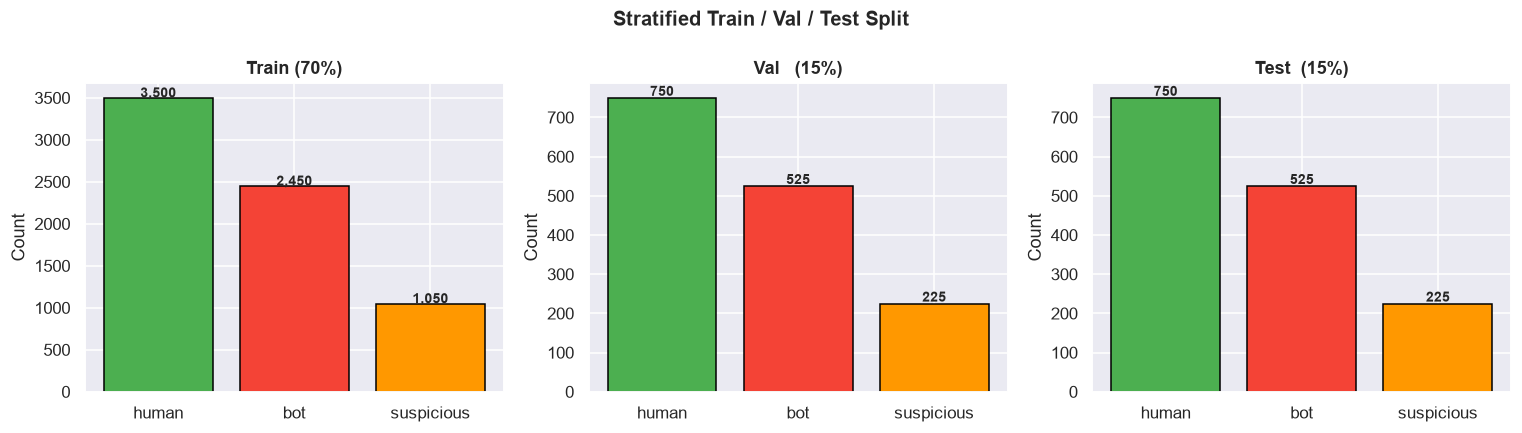

In [15]:
all_ids    = nodes_df['user_id'].values
all_labels = nodes_df['label'].values

train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    all_ids, all_labels, test_size=0.30, stratify=all_labels, random_state=42)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42)

print(f'Train : {len(train_ids):,}  ({len(train_ids)/len(all_ids)*100:.1f}%)')
print(f'Val   : {len(val_ids):,}  ({len(val_ids)/len(all_ids)*100:.1f}%)')
print(f'Test  : {len(test_ids):,}  ({len(test_ids)/len(all_ids)*100:.1f}%)')

label_names = {0: 'human', 1: 'bot', 2: 'suspicious'}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (ids, lbls, title) in zip(axes, [
    (train_ids, train_labels, 'Train (70%)'),
    (val_ids,   val_labels,   'Val   (15%)'),
    (test_ids,  test_labels,  'Test  (15%)'),
]):
    unique, counts = np.unique(lbls, return_counts=True)
    labels_str = [label_names[u] for u in unique]
    bars = ax.bar(labels_str, counts,
                  color=['#4CAF50','#F44336','#FF9800'][:len(unique)], edgecolor='black')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{cnt:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Stratified Train / Val / Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'split_distribution.png'), bbox_inches='tight', dpi=120)
plt.show()

## 3.9 Save All Processed Files

In [16]:
nodes_df.to_csv(PROCESSED_DIR    / 'nodes_clean.csv',  index=False)
edges_df.to_csv(PROCESSED_DIR    / 'edges_clean.csv',  index=False)
tweets_clean.to_csv(PROCESSED_DIR / 'tweets_clean.csv', index=False)

pd.DataFrame({'user_id': train_ids, 'label': train_labels}).to_csv(SPLITS_DIR / 'train_ids.csv', index=False)
pd.DataFrame({'user_id': val_ids,   'label': val_labels  }).to_csv(SPLITS_DIR / 'val_ids.csv',   index=False)
pd.DataFrame({'user_id': test_ids,  'label': test_labels }).to_csv(SPLITS_DIR / 'test_ids.csv',  index=False)

print('data/processed/')
for p in sorted(PROCESSED_DIR.iterdir()):
    print(f'  {p.name:<32}  {p.stat().st_size/1024:.1f} KB')
print('data/splits/')
for p in sorted(SPLITS_DIR.iterdir()):
    print(f'  {p.name:<32}  {p.stat().st_size/1024:.1f} KB')

data/processed/
  edges_clean.csv                   2797.2 KB
  feature_correlation.png           162.0 KB
  feature_types.json                0.6 KB
  interaction_encoding.json         0.1 KB
  label_encoding.json               0.2 KB
  missing_values.png                20.4 KB
  nodes_clean.csv                   1455.9 KB
  outlier_caps.json                 0.2 KB
  split_distribution.png            48.1 KB
  tweets_clean.csv                  19591.6 KB
  uid_to_idx.json                   155.2 KB
data/splits/
  test_ids.csv                      14.7 KB
  train_ids.csv                     68.4 KB
  val_ids.csv                       14.7 KB


## 3.10 Final Validation Assertions

In [17]:
NODE_FEATURE_COLS = ['account_age_days', 'followers_count', 'following_count', 'post_count', 'listed_count', 'verified', 'has_profile_image', 'has_description', 'default_profile', 'profile_completeness', 'posts_per_day', 'reply_ratio', 'retweet_ratio', 'mention_ratio', 'url_ratio', 'hashtag_ratio', 'duplicate_content_ratio']

nc = pd.read_csv(PROCESSED_DIR / 'nodes_clean.csv')
ec = pd.read_csv(PROCESSED_DIR / 'edges_clean.csv')

assert nc['user_id'].nunique() == len(nc),                   'user_id must be unique'
assert nc[NODE_FEATURE_COLS].isnull().sum().sum() == 0,       'No NaN in features'
assert ec[['src_idx','tgt_idx']].isnull().sum().sum() == 0,  'No NaN in edge indices'
assert nc['label'].isin([0, 1, 2]).all(),                    'Labels must be 0, 1, or 2'

print('ALL ASSERTIONS PASSED')
print(f'nodes_clean.csv : {nc.shape}')
print(f'edges_clean.csv : {ec.shape}')
print()
print('Data is ready for Module 4 -- Behavioral Feature Engineering')

ALL ASSERTIONS PASSED
nodes_clean.csv : (10000, 24)
edges_clean.csv : (55000, 8)

Data is ready for Module 4 -- Behavioral Feature Engineering


## Module 3 Summary

| Step | Action | Result |
|------|--------|--------|
| Load | Read CSV files | 10k users, 137k tweets, 55k edges |
| Format | Inspect CSV / JSON / Edge list | All formats documented |
| Dedup | Remove duplicate keys | 0 duplicates found |
| Missing | Fill location, listed_count | 0 remaining NaN in features |
| Types | Parse dates, cast booleans | All types correct |
| Outliers | Cap at 99th percentile | 100 rows capped per column |
| IDs | Validate FKs, create node_idx | 0-9999 contiguous index |
| Encode | Labels 0/1/2, itype 0-3 | Saved JSON encodings |
| Split | 70/15/15 stratified | 7k / 1.5k / 1.5k |
| Save | nodes_clean, edges_clean, splits | All files verified |

**Next:** Module 4 — User Behavioral Feature Engineering
